# **Examen Corto 1 - Visión por Computadora**

- Paula Barillas - 22764
- Mónica Salvatierra - 22249

Link del repositorio: https://github.com/alee2602/EC1-VPC

## **Task 1 - Análisis**

Imagine que está diseñando el primer bloque de una arquitectura convolucional para procesar imágenes satelitales multiespectrales de entrada con dimensiones:

- $W = 256$
- $H = 256$
- $C = 4$ (RGB + Infrarrojo)

Tiene dos opciones de diseño para este primer bloque, asumiendo que ambas buscan extraer 64 canales de salida ($C_{out}=64$):

- **Opción A (Estilo AlexNet):** una capa convolucional con filtros de $7\times7$, stride de $2$ y padding de $0$.
- **Opción B (Estilo VGG):** tres capas convolucionales secuenciales con filtros de $3\times3$, stride de $1$ y padding de $1$, seguidas de una capa de Max-Pooling de $2\times2$ (stride $2$).

**Responda:**

1. Utilizando la fórmula espacial vista en clase,

$$
O = \left\lfloor\frac{W-K+2P}{S}\right\rfloor + 1
$$

calcule la dimensión espacial de salida ($W_{out}\times H_{out}$) para el tensor después de la **Opción A** y después de toda la **Opción B** (incluyendo el pooling). Muestre su procedimiento.

2. Calcule matemáticamente cuántos parámetros entrenables (pesos) requiere la **Opción A** vs. las capas convolucionales de la **Opción B**. Basado en la teoría del **Campo Receptivo**, justifique por qué la industria estandarizó la **Opción B**.




### **Opción A | estilo AlexNet**
- Una convolución: $K=7$, $S=2$, $P=0$, $C_{in}=4$, $C_{out}=64$.

#### **Tamaño espacial de salida**

$$
W_{out}=\left\lfloor\frac{256-7+2(0)}{2}\right\rfloor+1
=\left\lfloor\frac{249}{2}\right\rfloor+1
=124+1=125
$$

Por simetría, $H_{out}=125$.

**Resultado espacial Opción A:**

$$
125\times125\times64
$$

#### **Parámetros entrenables de la conv**
- Solo pesos (sin bias):

$$
\#\text{pesos}=K\cdot K\cdot C_{in}\cdot C_{out}
=7\cdot7\cdot4\cdot64=12{,}544
$$

- Si se incluye bias por filtro:

$$
12{,}544+64=12{,}608
$$

---

### **Opción B | estilo VGG**
- tres conv $3\times3$ con $S=1$, $P=1$.
- max-pooling $2\times2$ con stride $2$.

#### **Tamaño espacial tras cada convolución**
Para cada conv $3\times3$ con $S=1, P=1$:

$$
O=\left\lfloor\frac{W-3+2(1)}{1}\right\rfloor+1=W
$$

Entonces:
- Después de convolución 1: $256\times256$.
- Después de convolución 2: $256\times256$.
- Después de convolución 3: $256\times256$.

#### **Tamaño espacial tras el max-pooling**

$$
W_{out}=\left\lfloor\frac{256-2}{2}\right\rfloor+1
=\left\lfloor127\right\rfloor+1=128
$$

Por simetría, $H_{out}=128$.

**Resultado espacial Opción B (final):**

$$
128\times128\times64
$$

#### **Parámetros entrenables en las convolución de Opción B**
Asumiendo la progresión natural de canales:
- convolución 1: $4\rightarrow64$
- convolución 2: $64\rightarrow64$
- convolución 3: $64\rightarrow64$

**convolución 1:**

$$
3\cdot3\cdot4\cdot64=2{,}304
$$

**convolución 2:**

$$
3\cdot3\cdot64\cdot64=36{,}864
$$

**convolución 3:**

$$
3\cdot3\cdot64\cdot64=36{,}864
$$

**Total (sin bias):**

$$
2{,}304+36{,}864+36{,}864=76{,}032
$$

**Total (con bias):**

$$
(2{,}304+64)+(36{,}864+64)+(36{,}864+64)=76{,}224
$$

---

### **Justificación**

Al analizar los resultados, se observa que la opción B tiene más parámetros que la opción A, ya que después de la primera convolución la red pasa de $C_{in}=4$ a $64$ y posteriormente mantiene dos transiciones $64\rightarrow64$. Sin embargo, la elección de arquitecturas tipo VGG no se basa únicamente en el número de parámetros en una capa aislada, sino en su capacidad para construir mejores representaciones de manera progresiva. Tres capas convolucionales de $3\times3$ logran un campo receptivo efectivo similar al de una capa $7\times7$, pero de forma jerárquica y por etapas. 

Ya que primero capturan detalles locales por ejemplo, textura de vegetación o suelo húmedo en imágenes satelitales, ya luego patrones más complejos como zonas urbanas y finalmente clases semánticas. Para entender un poco mejor, lo vimos cómo reconocemos un rostro por partes bordes, rasgos, identidad o bien cómo evaluamos si una fruta está madura usando varias señales color, textura y firmeza en lugar de una sola mirada rápida. Asimismo, cada capa adicional introduce una no linealidad (ReLU), lo que mejora la capacidad para distinguir casos difíciles y aumenta la robustez ante ruido, sombras, cambios de ángulo y oclusiones parciales, como por ejemplo, cuando identificamos a una persona aunque use gorra o se cambie el color de cabello. Por ello, en general, el diseño modular de bloques repetibles ($3\times3$ + $3\times3$ + pooling) facilita escalar, mantener y transferir modelos a nuevos problemas.

## **Task 2 - Criterio**

Una cooperativa agrícola en Guatemala los ha contratado para automatizar la detección de enfermedades en cultivos de mango. El gerente de TI de la cooperativa sugiere usar algoritmos tradicionales (SIFT y HOG combinados con un SVM) porque "son más ligeros y no requieren GPUs". Ustedes, como directores del proyecto de IA, proponen utilizar un enfoque basado en Deep Learning usando Transfer Learning con una arquitectura clásica. 

Respondan:


1. **Redacte una justificación técnica (máximo 2 párrafos) dirigida al gerente de TI explicando por qué SIFT/HOG fallarían en un entorno agrícola real frente a variaciones de luz, ángulos y oclusiones, y cómo los "Mapas de Características" de una red profunda solucionan la variabilidad semántica.**

    En un entorno agrícola, las imágenes de las hojas pueden variar considerablemente debido a factores como cambios en la iluminación, diferentes ángulos de captura o la presencia de elementos que cubren parcialmente la hoja, como otras hojas o ramas. Este tipo de variaciones afecta directamente la apariencia visual de la hoja en la imagen. Métodos como SIFT o HOG se basan principalmente en detectar patrones locales como bordes o cambios de intensidad en la imagen. Cuando las condiciones cambian, los patrones que estos métodos utilizan también cambian, provocando que las características extraídas no siempre representen de forma consistente la presencia de una enfermedad en la hoja.

    No obstante, las redes neuronales abordan este problema mediante el uso de mapas de características, que permiten aprender patrones visuales en distintos niveles de la red. Las primeras capas detectan estructuras simples como bordes o texturas, mientras que las capas más profundas combinan esta información para reconocer patrones más complejos relacionados con la forma y las características visuales de una enfermedad. Gracias a este proceso, el modelo puede aprender representaciones más estables de la imagen y mantener un buen desempeño incluso cuando cambian condiciones como la iluminación, el ángulo de la cámara o cuando partes de la hoja quedan cubiertas por otros elementos presentes en el cultivo.

2. **Si tuviera que elegir estrictamente entre usar la arquitectura AlexNet o VGG-16 para extraer características de las hojas, ¿cuál elegiría y por qué? Justifique su respuesta basándote en la modularidad, la no-linealidad (ReLU) y la capacidad de abstracción de capas profundas.**

    Si tuviera que elegir entre AlexNet y VGG-16 para extraer características de las hojas, elegiría VGG-16. Una de las razones principales es que su arquitectura es más modular, dado que utiliza varias capas convolucionales pequeñas de 3×3 que se aplican de forma secuencial. El diseño permite que la red vaya construyendo las características de manera progresiva, pasando de patrones simples como bordes o texturas a representaciones mucho más complejas relacionadas con la estructura de la hoja o los patrones de una enfermedad.

    Además, el uso de la función de activación ReLU introduce no-linealidad en cada capa, permitiendo que la red aprenda relaciones más complejas dentro de la imagen. Al tener mayor profundidad que AlexNet, VGG-16 también tiene más capacidad para generar representaciones visuales más abstractas. Esto es realmente útil cuando se utiliza transfer learning, ya que las capas convolucionales preentrenadas pueden extraer características bastante sútiles para clasificar correctamente los distintos tipos de enfermedades en las hojas.

## **Task 3 - Implementación**

### **1. Importar librerías necesarias**

In [ ]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


### **2. Cargar dataset**

In [4]:
dataset = datasets.ImageFolder(
    root="data/mango_leaf_disease_dataset",
    transform=train_transforms
)

print(dataset.classes)

['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']


### **3. Data Augmentation**

In [23]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### **4. Separar conjuntos de train/test**

In [22]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset,[train_size,test_size])

### **5. DataLoaders**

In [24]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

In [25]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


### **6. Cargar modelo preentrenado**

In [8]:
model = models.vgg16(pretrained=True)

c:\Users\ALEJANDRA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ALEJANDRA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\ALEJANDRA/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100.0%


### **7. Congelar las capas**

In [9]:
for param in model.features.parameters():
    param.requires_grad = False

### **8. Clasificador**

In [27]:
num_classes = len(dataset.classes)

model.classifier[6] = nn.Linear(4096,num_classes)

model = model.to(device)

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cpu


### **9. Loss y optimizador**

In [29]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

### **10. Training loop**

In [30]:
epochs = 8 

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()          # limpia gradientes
        outputs = model(images)        # forward
        loss = criterion(outputs, labels)
        loss.backward()                # backprop
        optimizer.step()               # update de los pesos

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.4f}")

Epoch 1/8 - Loss: 0.5827 - Acc: 0.8372
Epoch 2/8 - Loss: 0.4747 - Acc: 0.8825
Epoch 3/8 - Loss: 0.6689 - Acc: 0.8797
Epoch 4/8 - Loss: 0.5518 - Acc: 0.8934
Epoch 5/8 - Loss: 0.4314 - Acc: 0.9144
Epoch 6/8 - Loss: 0.4737 - Acc: 0.9081
Epoch 7/8 - Loss: 0.5283 - Acc: 0.9134
Epoch 8/8 - Loss: 0.5779 - Acc: 0.9141


### **11. Evaluación**

In [31]:
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:

num_classes = len(dataset.classes)
conf_matrix = torch.zeros(num_classes, num_classes, dtype=torch.int64)

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        for t, p in zip(labels.view(-1), preds.view(-1)):
            conf_matrix[t.long(), p.long()] += 1

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")
print("Confusion Matrix:\n", conf_matrix)

Test Accuracy: 0.9450
Confusion Matrix:
 tensor([[ 88,   0,   0,   0,   3,   7,   0,   0],
        [  0, 103,   0,   0,   0,   1,   0,   8],
        [  1,   0, 117,   1,   0,   0,   0,   0],
        [  0,   0,   0,  90,   0,   1,   0,   0],
        [  1,   0,   0,   0,  89,   8,   1,   1],
        [  0,   0,   0,   0,   1, 103,   0,   0],
        [  0,   0,   0,   0,   1,   0,  76,   0],
        [  0,   0,   0,   0,   4,   4,   1,  90]])


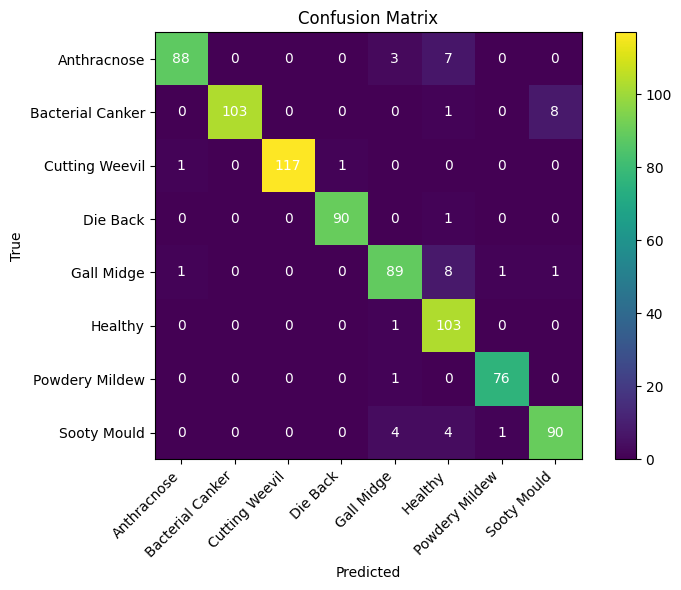

In [42]:
plt.figure(figsize=(8,6))
plt.imshow(conf_matrix.cpu().numpy())

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.xticks(range(num_classes), dataset.classes, rotation=45, ha="right")
plt.yticks(range(num_classes), dataset.classes)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, conf_matrix[i, j].item(),
                 ha="center", va="center", color="white")

plt.colorbar()
plt.tight_layout()
plt.show()

### **Conclusión**

El desempeño del modelo en el conjunto de prueba y la concentración de valores en la diagonal de la matriz de confusión demuestran que el modelo generaliza muy bien. Durante el entrenamiento, no se observó un sobreajuste significativo. Además, el uso de Dropout ayudó a reducir el riesgo de overfitting al desactivar neuronas de manera aleatoria durante el entrenamiento.

---------------------------------------------------------------------------------------------------------------------------------

#### **Prompt utilizado**

Generate a minimal PyTorch skeleton for image classification using transfer learning with VGG-16. Include a basic data augmentation pipeline (resize, random horizontal flip, rotation), and a simple training loop.

#### **Cómo se utilizó la respuesta**

La respuesta se utilizó únicamente como referencia para la estructura inicial del pipeline de datos y ejemplos de data augmentation. A partir de ese esqueleto, el código fue adaptado manualmente al problema del dataset de hojas de mango, puesto que se ajustaron las transformaciones, se cargó el dataset local con ImageFolder, se reemplazó la capa final del modelo para coincidir con el número de clases y se implementó el entrenamiento y la evaluación requeridos en el enunciado.

#### **Por qué el prompt funcionó**

El prompt fue efectivo porque especificaba claramente el framework (PyTorch), el modelo preentrenado (VGG-16) y los componentes necesarios del pipeline (data augmentation, dataset loading y training loop). Esto permitió obtener un punto de partida estructurado que luego se modificó para cumplir con los requisitos específicos del task.